# Chapter 09 텍스트를 위한 인공 신경망
## 09-2 순환 신경망으로 IMDB 리뷰 분류하기
### IMDB 리뷰 데이터셋

> 자연어 처리와 말뭉치란 무엇인가요?
> * 자연어 처리(natural language processing, NLP)는 컴퓨터를 사용해 인간의 언어를 처리하는 분야. 대표적인 세부 분야로는 음성 인식, 기계 번역, 감성 분석 등. IMDB 리뷰를 감상평에 따라 분류하는 작업은 감성 분석에 해당. 자연어 처리 분야에서는 훈련 데이터를 종종 **말뭉치(corpus)**라고 부름. 예를 들어 IMDB 리뷰 데이터셋이 하나의 말뭉치.

* 사실 텍스트 자체를 신경망에 전달하지는 않음. 컴퓨터에서 처리하는 모든 것은 어떤 숫자 데이터. 앞서 합성곱 신경망에서 이미지를 다룰 때는 특별한 변환을 하지 않았음. 이미지가 정수 픽셀값으로 이루어져 있기 때문. 텍스트 데이터의 경우 단어를 숫자 데이터로 바꾸는 일반적인 방법은 데이터에 등장하는 단어마다 고유한 정수를 부여하는 것.
* 일반적으로 영어 문장은 모두 소문자로 바꾸고 구둣점을 삭제한 다음 공백을 기준으로 분리. 이렇게 분리된 단어를 **토큰token**이라고 부름. 하나의 샘플은 여러 개의 토큰으로 이루어져 있고 1개의 토큰이 하나의 타임스텝에 해당.

> 한글 문장은 어떻게 토큰을 분리하나요?
> * 한글은 조사가 발달되어 있기 때문에 공백으로 나누는 것만으로는 부족. 일반적으로 한글은 형태소 분석을 통해 토큰을 만듦. 안타깝지만 한글의 형태소 분석은 이 책의 범위를 넘어섦. KoNLPy를 사용한 한글의 형태소 분석에 관심이 있다면 『파이썬 라이브러리를 활용한 머신러닝(개정판)』(2020, 한빛미디어)의 7장을 참고.

* 토큰에 할당하는 정수 중에 몇 개는 특정한 용도로 예약되어 있는 경우가 많음. 예를 들어 0은 패딩, 1은 문장의 시작, 2는 어휘 사전에 없는 토큰.

> 어휘 사전은 또 뭐죠?
> * 훈련 세트에서 고유한 단어를 뽑아 만든 목록. 예를 들어 테스트 세트 안에 어휘 사전에 없는 단어가 있다면 2로 변환하여 신경망 모델에 주입.

* 실제 IMDB 리뷰 데이터셋은 영어로 된 문장이지만 편리하게도 텐서플로에는 이미 정수로 바꾼 데이터가 포함되어 있음.

In [1]:
from tensorflow.keras.datasets import imdb
(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=500)

In [3]:
print(train_input.shape, test_input.shape)

(25000,) (25000,)


In [4]:
print(train_input[0]) # 첫 번째 리뷰에 담긴 내용 출력

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 458, 2, 66, 2, 4, 173, 36, 256, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 2, 2, 17, 2, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 469, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2, 2, 16, 480, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 2, 15, 256, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 476, 26, 400, 317, 46, 7, 4, 2, 2, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 2, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 2, 88, 12, 16, 283, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]


> 어떤 기준으로 500개의 단어를 고른 것인가요?
> * imdb.load_data() 함수는 전체 어휘 사전에 있는 단어를 등장 횟수 순서대로 나열한 다음 가장 많이 등장한 500개의 단어를 선택.

In [5]:
print(train_target[:20])

[1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 1]


* 해결할 문제는 리뷰가 긍정인지 부정인지를 판단하는 것. 그러면 이진 분류 문제로 볼 수 있으므로 타깃값이 0(부정)과 1(긍정)로 나누어짐.

In [6]:
from sklearn.model_selection import train_test_split
train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42
)

In [7]:
import numpy as np
lengths = np.array([len(x) for x in train_input])

In [8]:
print(np.mean(lengths), np.median(lengths)) # 리뷰 길이의 평균과 중간값

239.00925 178.0


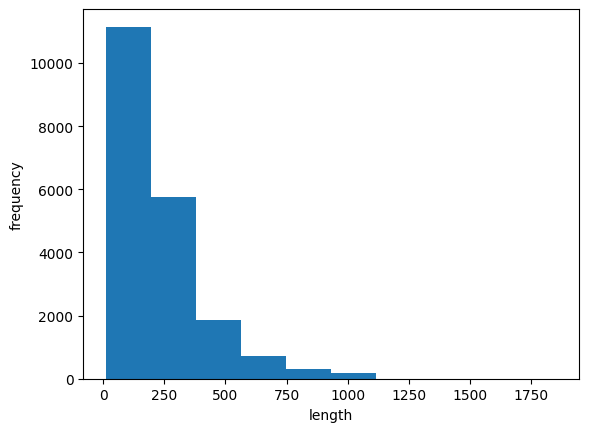

In [9]:
import matplotlib.pyplot as plt
plt.hist(lengths)
plt.xlabel('length')
plt.ylabel('frequency')
plt.show()

* 역시 한쪽으로 치우쳤음. 대부분의 리뷰 길이는 300 미만.
* 리뷰는 대부분 짧아서 이 예제에서는 중간값보다 훨씬 짧은 100개의 단어만 사용하겠음. 하지만 여전히 100개의 단어보다 작은 리뷰가 있음. 이런 리뷰들의 길이를 100에 맞추기 위해 패딩이 필요. 보통 패딩을 나타내는 토큰으로는 0을 사용.

In [7]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
train_seq = pad_sequences(train_input, maxlen=100)

NameError: name 'train_input' is not defined

* maxlen에 원하는 길이를 지정하면 이보다 긴 경우는 잘라내고 짧은 경우는 0으로 패딩.

In [11]:
print(train_seq.shape)

(20000, 100)


In [12]:
print(train_seq[0])

[ 10   4  20   9   2 364 352   5  45   6   2   2  33 269   8   2 142   2
   5   2  17  73  17 204   5   2  19  55   2   2  92  66 104  14  20  93
  76   2 151  33   4  58  12 188   2 151  12 215  69 224 142  73 237   6
   2   7   2   2 188   2 103  14  31  10  10 451   7   2   5   2  80  91
   2  30   2  34  14  20 151  50  26 131  49   2  84  46  50  37  80  79
   6   2  46   7  14  20  10  10 470 158]


In [13]:
print(train_input[0][-10:])

[6, 2, 46, 7, 14, 20, 10, 10, 470, 158]


* train_seq[0]의 출력값과 비교하면 정확히 일치. 그렇다면 샘플의 앞부분이 잘렸다는 것을 짐작할 수 있겠음.
* `pad_sequences()` 함수는 기본으로 maxlen보다 긴 시퀀스의 앞부분을 자름. 이렇게 하는 이유는 일반적으로 시퀀스의 뒷부분의 정보가 더 유용하리라 기대하기 때문. 영화 리뷰 데이터를 생각해 보면 리뷰 끝에 뭔가 결정적인 소감을 말할 가능성이 높다고 볼 수 있음. 만약 시퀀스의 뒷부분을 잘라내고 싶다면 `pad_sequences()` 함수의 truncating 매개변수의 값을 기본값 'pre'가 아닌 'post'로 바꾸면 됨.

In [14]:
print(train_seq[5]) # 앞부분에 0이 있는 것으로 보아 이 샘플의 길이는 100이 안 됨.

[  0   0   0   0   1   2 195  19  49   2   2 190   4   2 352   2 183  10
  10  13  82  79   4   2  36  71 269   8   2  25  19  49   7   4   2   2
   2   2   2  10  10  48  25  40   2  11   2   2  40   2   2   5   4   2
   2  95  14 238  56 129   2  10  10  21   2  94 364 352   2   2  11 190
  24 484   2   7  94 205 405  10  10  87   2  34  49   2   7   2   2   2
   2   2 290   2  46  48  64  18   4   2]


In [15]:
val_seq = pad_sequences(val_input, maxlen=100)

### 순환 신경망 만들기
* IMDB 리뷰 분류 문제는 이진 분류이므로 마지막 출력층은 1개의 뉴런을 가지고 시그모이드 활성화 함수를 사용해야 함.

> Sequential 클래스가 순환 신경망을 만드는 용도인가요?
> * 아님. 이전 장에서 보았듯이 Sequential 클래스는 순환 신경망뿐만 아니라 합성곱 신경망이나 일반적인 인공 신경망 모델을 모두 만들 수 있음. 다만 층을 순서대로 쌓기 때문에 Sequential 클래스로 이름을 붙였음.

In [3]:
from tensorflow import keras
model = keras.Sequential()
model.add(keras.layers.SimpleRNN(8, input_shape=(100, 500))) # 샘플의 길이 100
model.add(keras.layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


* input_shape의 두 번째 차원인 500은 어디서 온 숫자일까? 이전 섹션에서 만든 train_seq와 val_seq에는 한 가지 큰 문제가 있음. 토큰을 정수로 변환한 이 데이터를 신경망에 주입하면 큰 정수가 큰 활성화 출력을 만들기 때문.
분명히 이 정수 사이에는 어떤 관련이 없음. 20번 토큰을 10번 토큰보다 더 중요시해야 할 이유가 없음. 따라서 단순한 정숫값을 신경망에 입력하기 위해서는 다른 방식을 찾아야 함.
* 정숫값에 있는 크기 속성을 없애고 각 정수를 고유하게 표현하는 방법은 7장에서 잠깐 보았던 원-핫 인코딩.
* `imdb.load_data()` 함수에서 500개의 단어만 사용하도록 지정했기 때문에 고유한 단어는 모두 500개. 즉 훈련 데이터에 포함될 수 있는 정숫값의 범위는 0(패딩 토큰)에서 499까지. 따라서 이 범위를 원-핫 인코딩으로 표현하려면 배열의 길이가 500이어야 함!
* 토큰마다 500개의 숫자를 사용해 표현. 다만 500개 중에 하나만 1이고 나머지는 모두 0으로 만들어 정수 사이에 있던 크기 속성을 없애는 원-핫 인코딩을 사용.

In [17]:
train_oh = keras.utils.to_categorical(train_seq)

In [18]:
print(train_oh.shape)

(20000, 100, 500)


* 정수 하나마다 모두 500차원의 배열로 변경되었기 때문에 (20000, 100) 크기의 train_seq가 (20000, 100, 500) 크기의 train_oh로 바뀌었음. 이렇게 샘플 데이터의 크기가 1차원 정수 배열 (100, )에서 2차원 배열(100, 500)로 바꿔야 하므로 SimpleRNN 클래스의 input_shape 매개변수의 값을 (100, 500)으로 지정한 것.

In [19]:
print(train_oh[0][0][:12])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


In [20]:
print(np.sum(train_oh[0][0]))

1.0


* 열한 번째 원소만 1이고 나머지는 모두 0이어서 원-핫 인코딩된 배열의 값을 모두 더한 결과가 1이 되었음.

In [21]:
val_oh = keras.utils.to_categorical(val_seq)

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 8)              │         4,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,081 (15.94 KB)

 Trainable params: 4,081 (15.94 KB)

 Non-trainable params: 0 (0.00 B)

* 입력 토큰은 500차원의 원-핫 인코딩 배열. 이 배열이 순환층의 뉴런 8개와 완전히 연결되기 때문에 총 500 $\times$ 8 = 4,000개의 가중치가 있음. 순환층의 은닉 상태는 다시 다음 타임스텝에 사용되기 위해 또 다른 가중치와 곱해짐. 이 은닉 상태도 순환층의 뉴런과 완전히 연결되기 때문에 8(은닉 상태 크기) $\times$ 8(뉴런 개수) = 64개의 가중치가 필요. 마지막으로 뉴런마다 하나의 절편이 있음. 따라서 모두 4,000 + 64 + 8 = 4,072개의 모델 파라미터가 필요.

### 순환 신경망 훈련하기
* 이 예에서는 기본 RMSprop의 학습률 0.001을 사용하지 않기 위해 별도의 RMSprop 객체를 만들어 학습률을 0.0001로 지정. 그다음 에포크 횟수를 100으로 늘리고 배치 크기는 64개로 설정.

In [1]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model.compile(optimizer=rmsprop, loss='binary_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-simplernn-model.h5', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history = model.fit(train_oh, train_target, epochs=100, batch_size=64, validation_data=(val_oh, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

NameError: name 'keras' is not defined

* 이 훈련은 서른다섯 번째 에포크에서 조기 종료되었음. 검증 세트에 대한 정확도는 약 80% 정도. 매우 뛰어난 성능은 아니지만 감상평을 분류하는 데 어느 정도 성과를 내고 있다고 판단할 수 있음.

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

* 훈련 손실은 꾸준히 감소하고 있지만 검증 손실은 대략 스무 번째 에포크에서 감소가 둔해지고 있음. 적절한 에포크에서 훈련을 멈춘 것 같음. 성공.
* 원-핫 인코딩의 단점은 입력 데이터가 엄청 커진다는 것.

In [1]:
print(train_seq.nbytes, train_oh.nbytes)

NameError: name 'train_seq' is not defined

### 단어 임베딩을 사용하기
* 순환 신경망에서 텍스트를 처리할 때 즐겨 사용하는 방법은 **단어 임베딩word embedding**. 단어 임베딩은 각 단어를 고정된 크기의 실수 벡터로 바꾸어 줌.
* 이런 단어 임베딩으로 만들어진 벡터는 원-핫 인코딩된 벡터보다 훨씬 의미 있는 값으로 채워져 있기 때문에 자연어 처리에서 더 좋은 성능을 내는 경우가 많음.
* 단어 임베딩의 장점은 입력으로 정수 데이터를 받는다는 것. 즉 원-핫 인코딩으로 변경된 train_oh 배열이 아니라 train_seq를 사용할 수 있음. 이 때문에 메모리를 훨씬 효율적으로 사용할 수 있음.

In [4]:
model2 = keras.Sequential()
model2.add(keras.layers.Embedding(500, 16, input_length=100))
model2.add(keras.layers.SimpleRNN(8))
model2.add(keras.layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [5]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model2.compile(optimizer=rmsprop, loss='binary_corssentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-embedding-moel.h5', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history = model2.fit(train_seq, train_target, epochs=100, batch_size=64, validation_data=(val_seq, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

NameError: name 'train_seq' is not defined

* 출력 결과를 보면 원-핫 인코딩을 사용한 모델과 비슷한 성능을 냈음. 반면에 순환층의 가중치 개수는 훨씬 작고 훈련 세트 크기도 훨씬 줄어들었음.

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

* 검증 손실이 더 감소되지 않아 훈련이 적절히 조기 종료된 것 같음. 이에 비해 훈련 손실은 계속 감소.